In [18]:
import pandas as pd 
import numpy as np
#para temas graficas 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
df = pd.read_csv(r"data\titanic_limpio.csv")

In [3]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin datos,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


### Porcentaje de supervivientes

In [4]:
porcentaje_supervivientes = df['Survived'].mean() * 100

porcentaje_supervivientes

np.float64(38.38383838383838)

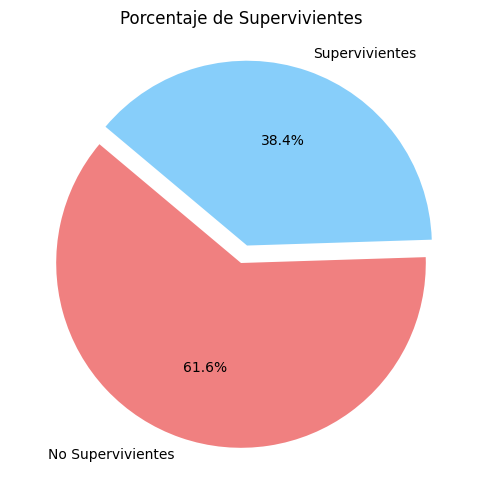

In [ ]:
# Crear una gráfica de pastel para el porcentaje de supervivientes
plt.figure(figsize=(6, 6))
labels = ['No Supervivientes', 'Supervivientes']
sizes = [100 - porcentaje_supervivientes, porcentaje_supervivientes]
colors = ['lightcoral', 'lightskyblue']
explode = (0, 0.1)  # resaltar la porción de los supervivientes

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Porcentaje de Supervivientes')
plt.show()
#sizes: define qué tan grande es cada porción
#explode: para resaltar la segunda porción
#labels: para nombrar cada porción
#colors: define los colores
#autopct='%1.1f%%': muestra el porcentaje con un decimal (ej: 38.5%)
#startangle=140: rota el gráfico para que comience en un ángulo de 140 grados

In [5]:
supervivientes_por_clase = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean'])
supervivientes_por_clase.columns = ['Total_Pasajeros', 'Supervivientes', 'Porcentaje']
supervivientes_por_clase['Porcentaje'] = supervivientes_por_clase['Porcentaje'] * 100


supervivientes_por_clase

,Total_Pasajeros,Supervivientes,Porcentaje
Pclass,,,
1,216,136,62.962963
2,184,87,47.282609
3,491,119,24.236253


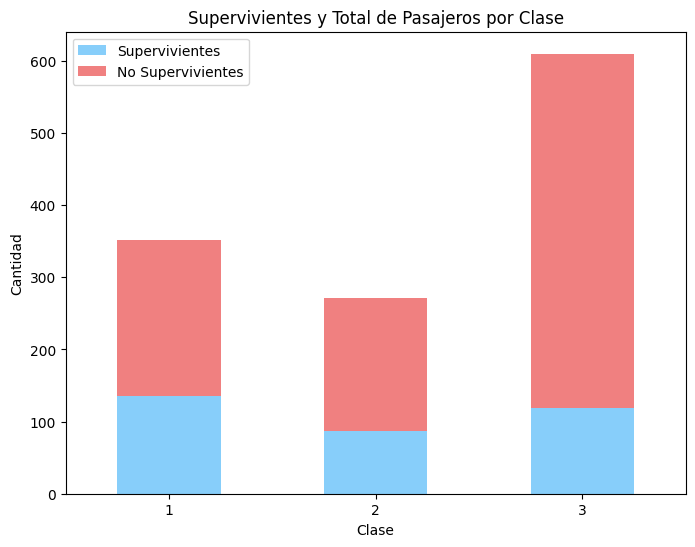

In [20]:
# Gráfico de barras apiladas para mostrar supervivientes por clase
supervivientes_por_clase[['Supervivientes', 'Total_Pasajeros']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 6), 
    color=['lightskyblue', 'lightcoral']
)

plt.title('Supervivientes y Total de Pasajeros por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.legend(['Supervivientes', 'No Supervivientes'])
plt.xticks(rotation=0)
plt.show()

### los apellido más repetidos por clase

In [ ]:
df['Apellido'] = df['Name'].str.split(',').str[0]

apellidos_por_clase = df.groupby(['Pclass', 'Apellido']).size().reset_index(name='Frecuencia') # contamos con el size con el nombre frecuencia basado en pcclass y apellido

# apellidos más comunes por clase
apellidos_mas_comunes = apellidos_por_clase.sort_values(['Pclass', 'Frecuencia'], ascending=[True, False])

# creamos un DataFrame con los 3 apellidos más comunes por clase
top_apellidos_por_clase = (apellidos_mas_comunes.groupby('Pclass')
                           .apply(lambda x: x.nlargest(3, 'Frecuencia'))
                           .reset_index(drop=True))


top_apellidos_por_clase

C:\Users\rey_d\AppData\Local\Temp\ipykernel_10532\613689901.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'Frecuencia'))


,Pclass,Apellido,Frecuencia
0,1,Carter,4
1,1,Fortune,4
2,1,Allison,3
3,2,Brown,3
4,2,Collyer,3
5,2,Hart,3
6,3,Andersson,9
7,3,Sage,7
8,3,Goodwin,6


C:\Users\rey_d\AppData\Local\Temp\ipykernel_10532\280995384.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


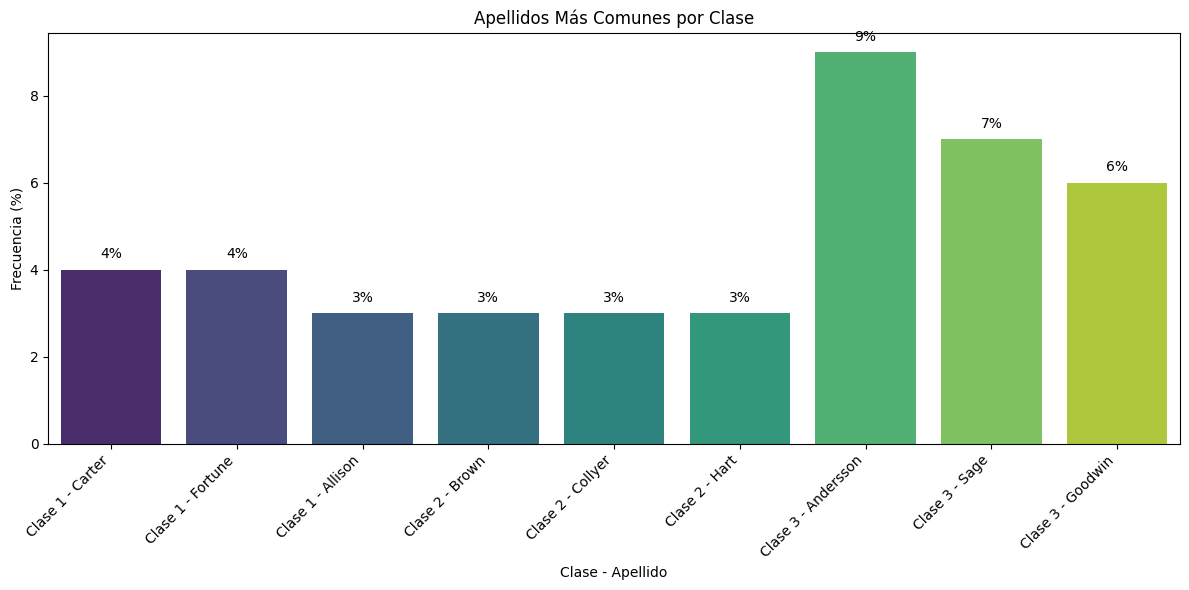

In [23]:
# Gráfico de barras agrupadas para los apellidos más comunes por clase
plt.figure(figsize=(12, 6))
top_apellidos_por_clase['Clase_Apellido'] = 'Clase ' + top_apellidos_por_clase['Pclass'].astype(str) + ' - ' + top_apellidos_por_clase['Apellido']

sns.barplot(
    data=top_apellidos_por_clase, 
    x='Clase_Apellido', 
    y='Frecuencia', 
    palette='viridis'
)

# Añadir etiquetas con el porcentaje
for index, row in top_apellidos_por_clase.iterrows():
    plt.text(
        index, 
        row['Frecuencia'] + 0.2, 
        f"{row['Frecuencia']}%", 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

plt.title('Apellidos Más Comunes por Clase')
plt.xlabel('Clase - Apellido')
plt.ylabel('Frecuencia (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
apellido_mas_comun = df['Apellido'].value_counts().nlargest(1)
apellido_mas_comun

Apellido
Andersson    9
Name: count, dtype: int64

### Precio medio por clase

In [8]:
precio_medio_por_clase = df.groupby('Pclass')['Fare'].agg(['mean', 'median', 'min', 'max', 'std'])
precio_medio_por_clase = precio_medio_por_clase.round(2)
precio_medio_por_clase

,mean,median,min,max,std
Pclass,,,,,
1,84.15,60.29,0.0,512.33,78.38
2,20.66,14.25,0.0,73.50,13.42
3,13.68,8.05,0.0,69.55,11.78


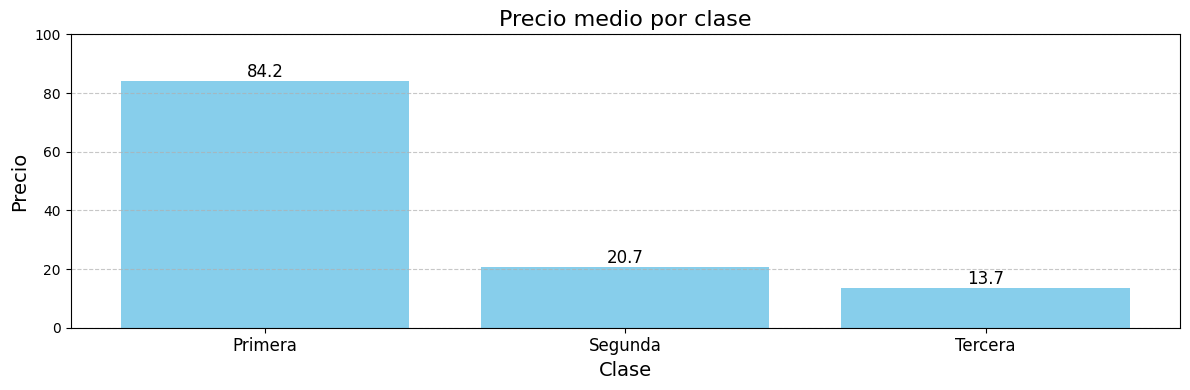

In [27]:
plt.figure(figsize=(12, 4))
# Crear el gráfico de barras
bars = plt.bar(precio_medio_por_clase.index, precio_medio_por_clase['mean'], color='skyblue')
# Añadir etiquetas a las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=12)
# Añadir etiquetas y títulos
plt.title('Precio medio por clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.xticks(precio_medio_por_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.ylim(0, 100)  # Ajustar el límite del eje y para que se vea mejor
# Añadir una cuadrícula
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Ajustar el gráfico
plt.show()  # Mostrar el gráfico

### edad por clase

In [9]:
edad_por_clase = df.groupby('Pclass')['Age'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
edad_por_clase = edad_por_clase.round(2)
edad_por_clase

,mean,median,min,max,std,count
Pclass,,,,,,
1,36.81,35.0,0.92,80.0,14.18,216
2,29.77,28.0,0.67,70.0,13.58,184
3,25.93,28.0,0.42,74.0,10.70,491


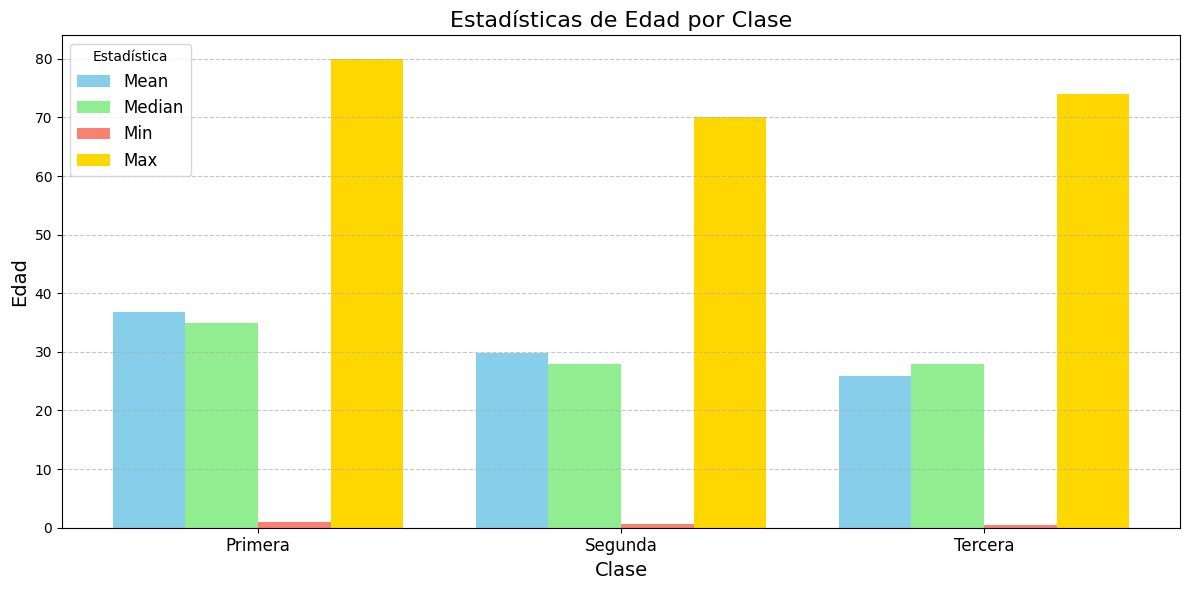

In [28]:
# Crear un gráfico de barras agrupadas para las estadísticas de edad por clase
plt.figure(figsize=(12, 6))

# Datos a graficar
estadisticas = ['mean', 'median', 'min', 'max']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

# Crear barras para cada estadística
for i, estadistica in enumerate(estadisticas):
    plt.bar(
        edad_por_clase.index + i * 0.2,  # Desplazamiento para agrupar las barras
        edad_por_clase[estadistica],
        width=0.2,
        label=estadistica.capitalize(),
        color=colors[i]
    )

# Configurar etiquetas y título
plt.title('Estadísticas de Edad por Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Edad', fontsize=14)
plt.xticks(edad_por_clase.index + 0.3, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.legend(title='Estadística', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### supervivientes por rangos de edad

In [10]:
bins = [0, 5, 12, 18, 35, 60, np.inf] #usando bins para establecer rangos
labels = ['Bebé (0-5)', 'Niño (5-12)', 'Adolescente (12-18)', 'Joven (18-35)', 'Adulto (35-60)', 'Mayor (60+)']
df['Rango_Edad'] = pd.cut(df['Age'], bins=bins, labels=labels)# creamos nuueva col para esos rangos

In [17]:
supervivientes_por_edad = df.groupby('Rango_Edad', observed=False)['Survived'].agg(['count', 'sum', 'mean'])
supervivientes_por_edad.columns = ['Total', 'Supervivientes', 'Porcentaje']
supervivientes_por_edad['Porcentaje'] = supervivientes_por_edad['Porcentaje'] * 100

In [12]:
supervivientes_por_edad

,Total,Supervivientes,Porcentaje
Rango_Edad,,,
Bebé (0-5),44,31,70.454545
Niño (5-12),25,9,36.000000
Adolescente (12-18),70,30,42.857143
Joven (18-35),535,189,35.327103
Adulto (35-60),195,78,40.000000
Mayor (60+),22,5,22.727273


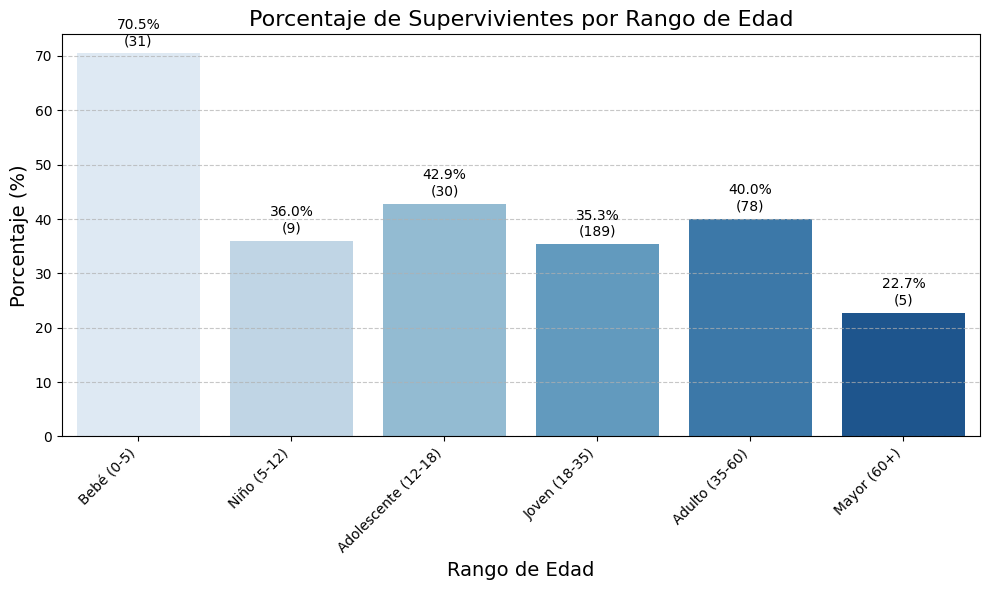

In [34]:
# Crear un gráfico de barras para el porcentaje de supervivientes por rango de edad
plt.figure(figsize=(10, 6))  # Configurar el tamaño de la figura
sns.barplot(
    data=supervivientes_por_edad.reset_index(),  # Usar los datos de supervivientes por rango de edad
    x='Rango_Edad',  # Eje x: los rangos de edad
    y='Porcentaje',  # Eje y: el porcentaje de supervivientes
    hue='Rango_Edad',  # Asignar el mismo valor de x a hue
    palette='Blues',  # Usar una paleta de colores en tonos azules
    dodge=False  # Evitar barras separadas
)

# Añadir etiquetas con el porcentaje y el número exacto de supervivientes
for index, row in supervivientes_por_edad.reset_index().iterrows():  # Iterar sobre cada fila del DataFrame
    plt.text(
        index,  # Posición en el eje x
        row['Porcentaje'] + 1,  # Posición en el eje y, ligeramente por encima de la barra
        f"{row['Porcentaje']:.1f}%\n({row['Supervivientes']})",  # Texto con el porcentaje y el número de supervivientes
        ha='center',  # Alinear el texto horizontalmente al centro
        va='bottom',  # Alinear el texto verticalmente en la parte inferior
        fontsize=10  # Tamaño de la fuente
    )

# Configurar etiquetas y título
plt.title('Porcentaje de Supervivientes por Rango de Edad', fontsize=16)  # Título del gráfico
plt.xlabel('Rango de Edad', fontsize=14)  # Etiqueta del eje x
plt.ylabel('Porcentaje (%)', fontsize=14)  # Etiqueta del eje y
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Añadir una cuadrícula en el eje y con líneas punteadas
plt.legend([], [], frameon=False)  # Ocultar la leyenda
plt.tight_layout()  # Ajustar el diseño para evitar solapamientos

# Mostrar el gráfico
plt.show()  # Renderizar y mostrar el gráfico

### % de supervencia entre hombres, mujeres y ninos por clase

In [13]:
df['GrupoEdadSexo'] = 'Adulto'
df.loc[df['Age'] < 12, 'GrupoEdadSexo'] = 'Niño'

df.loc[(df['Age'] >= 12) & (df['Sex'] == 'male'), 'GrupoEdadSexo'] = 'Hombre'
df.loc[(df['Age'] >= 12) & (df['Sex'] == 'female'), 'GrupoEdadSexo'] = 'Mujer'

supervivencia_grupo_clase = pd.pivot_table(
    df, 
    values='Survived',
    index='Pclass',
    columns='GrupoEdadSexo',
    aggfunc='mean'
) * 100

supervivencia_grupo_clase.round(2)

GrupoEdadSexo,Hombre,Mujer,Niño
Pclass,,,
1,35.29,97.85,75.00
2,8.08,91.18,100.00
3,12.07,50.41,40.43


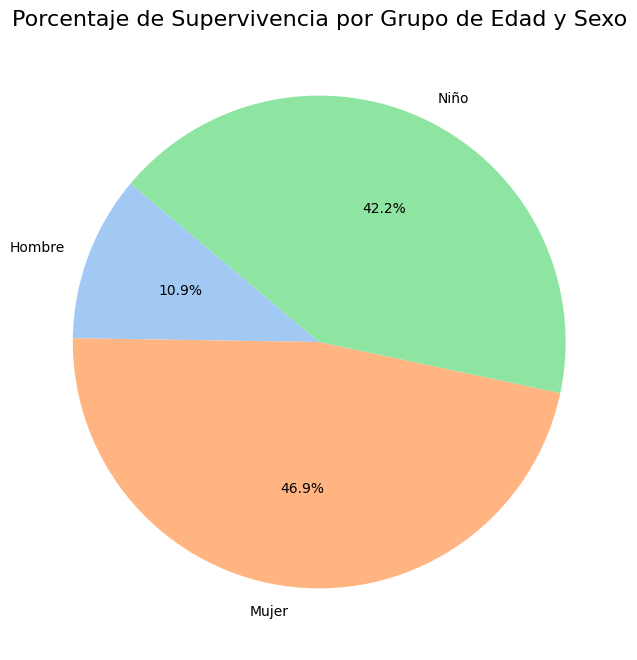

In [35]:
# Crear un gráfico de pastel para el porcentaje de supervivencia por grupo de edad y sexo
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')  # Usar una paleta de colores pastel

# Calcular el porcentaje total de supervivientes por grupo de edad y sexo
supervivencia_total = supervivencia_grupo_clase.sum(axis=0)

# Crear el gráfico de pastel
plt.pie(
    supervivencia_total, 
    labels=supervivencia_total.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors
)

# Configurar el título
plt.title('Porcentaje de Supervivencia por Grupo de Edad y Sexo', fontsize=16)

# Mostrar el gráfico
plt.show()

In [14]:
conteo_grupo_clase = pd.pivot_table(
    df, 
    values='PassengerId',
    index='Pclass',
    columns='GrupoEdadSexo',
    aggfunc='count'
)


conteo_grupo_clase

GrupoEdadSexo,Hombre,Mujer,Niño
Pclass,,,
1,119,93,4
2,99,68,17
3,323,121,47


<Figure size 1000x600 with 0 Axes>

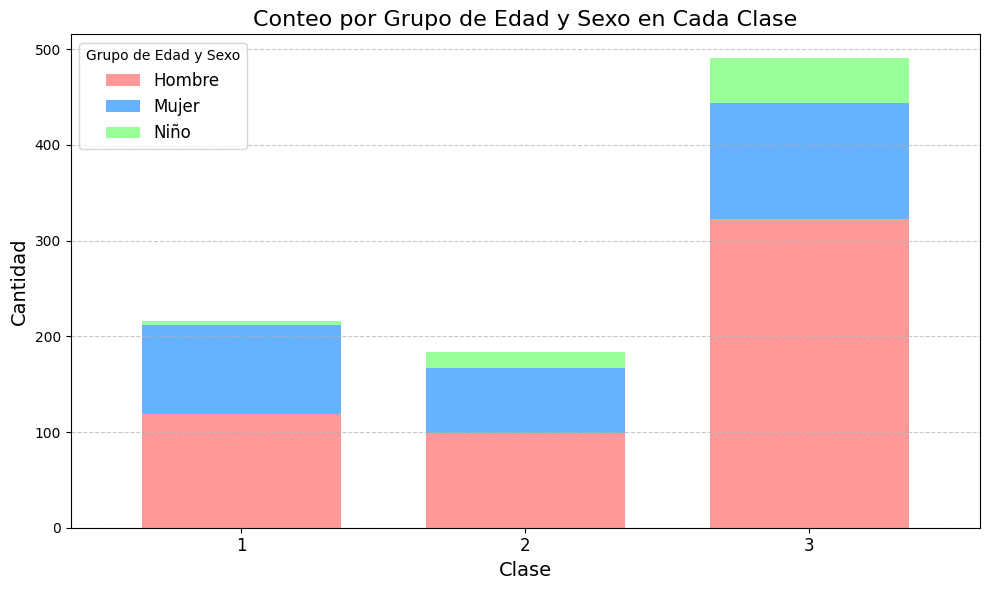

In [36]:
# Crear un gráfico de barras apiladas para mostrar el conteo por grupo de edad y sexo en cada clase
plt.figure(figsize=(10, 6))

# Colores personalizados para cada grupo
colors = ['#FF9999', '#66B2FF', '#99FF99']  # Tonos agradables: rojo claro, azul claro, verde claro

# Crear el gráfico de barras apiladas
conteo_grupo_clase.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(10, 6),
    width=0.7
)

# Configurar etiquetas y título
plt.title('Conteo por Grupo de Edad y Sexo en Cada Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Cantidad', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.legend(title='Grupo de Edad y Sexo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()



In [15]:
# tabla combinada con porcentaje y conteo
print("\nTabla combinada (porcentaje % [conteo]):")
tabla_combinada = supervivencia_grupo_clase.round(1).astype(str) + '% [' + conteo_grupo_clase.astype(str) + ']'
tabla_combinada


Tabla combinada (porcentaje % [conteo]):


GrupoEdadSexo,Hombre,Mujer,Niño
Pclass,,,
1,35.3% [119],97.8% [93],75.0% [4]
2,8.1% [99],91.2% [68],100.0% [17]
3,12.1% [323],50.4% [121],40.4% [47]


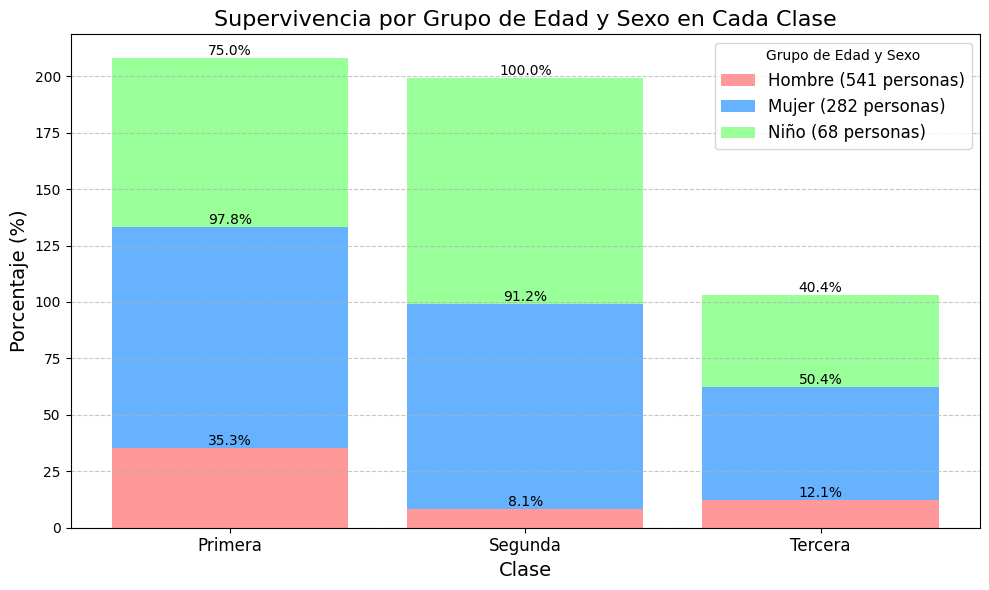

In [38]:
# Crear un gráfico de barras apiladas para la tabla combinada
plt.figure(figsize=(10, 6))

# Extraer los valores numéricos de la tabla combinada para graficar
valores = supervivencia_grupo_clase.values
conteos = conteo_grupo_clase.values

# Colores personalizados para cada grupo
colores = ['#FF9999', '#66B2FF', '#99FF99']  # Tonos agradables: rojo claro, azul claro, verde claro

# Crear las barras apiladas
for i, grupo in enumerate(supervivencia_grupo_clase.columns):
    bars = plt.bar(
        supervivencia_grupo_clase.index, 
        valores[:, i], 
        bottom=valores[:, :i].sum(axis=1), 
        color=colores[i], 
        label=f"{grupo} ({conteos[:, i].sum()} personas)"
    )
    # Añadir etiquetas con los valores en las barras
    for bar, valor in zip(bars, valores[:, i]):
        plt.text(
            bar.get_x() + bar.get_width() / 2, 
            bar.get_height() + bar.get_y(), 
            f"{valor:.1f}%", 
            ha='center', 
            va='bottom', 
            fontsize=10
        )

# Configurar etiquetas y título
plt.title('Supervivencia por Grupo de Edad y Sexo en Cada Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=14)
plt.xticks(supervivencia_grupo_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.legend(title='Grupo de Edad y Sexo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### supervivientes por sexo

In [16]:
supervivientes_por_sexo = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])
supervivientes_por_sexo.columns = ['Total', 'Supervivientes', 'Porcentaje']
supervivientes_por_sexo['Porcentaje'] = supervivientes_por_sexo['Porcentaje'] * 100

supervivientes_por_sexo.round(2)

,Total,Supervivientes,Porcentaje
Sex,,,
female,314,233,74.20
male,577,109,18.89


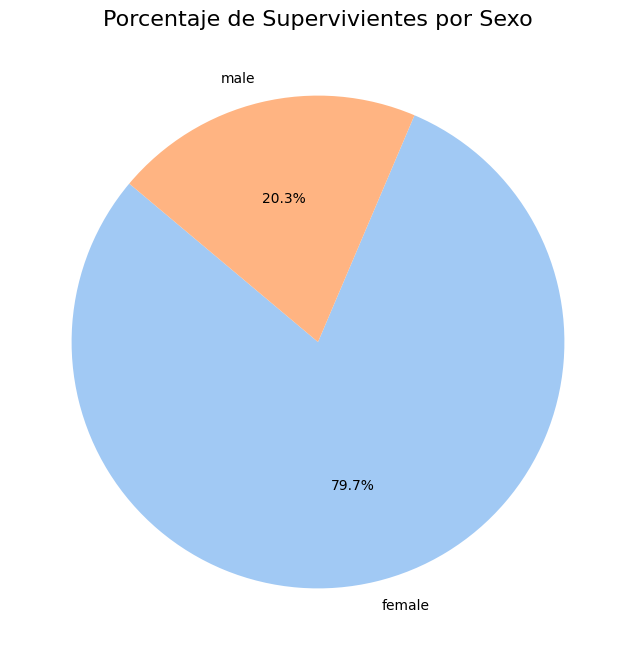

In [43]:
# Redefinir supervivientes_por_sexo correctamente
supervivientes_por_sexo = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])
supervivientes_por_sexo.columns = ['Total', 'Supervivientes', 'Porcentaje']
supervivientes_por_sexo['Porcentaje'] = supervivientes_por_sexo['Porcentaje'] * 100

# Crear un gráfico de pastel para el porcentaje de supervivientes por sexo
plt.figure(figsize=(8, 8))
labels = supervivientes_por_sexo.index  # Etiquetas para cada segmento
sizes = supervivientes_por_sexo['Porcentaje']  # Porcentajes de supervivencia
colors = sns.color_palette('pastel')  # Paleta de colores pastel

# Crear el gráfico de pastel
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors
)

# Configurar el título
plt.title('Porcentaje de Supervivientes por Sexo', fontsize=16)

# Mostrar el gráfico
plt.show()

C:\Users\rey_d\AppData\Local\Temp\ipykernel_10532\2179840499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


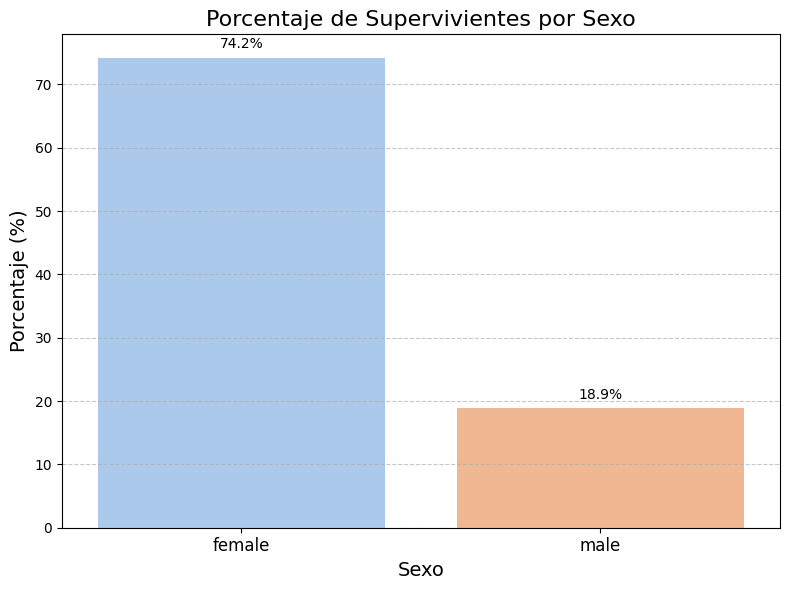

In [44]:
# Redefinir supervivientes_por_sexo correctamente
supervivientes_por_sexo = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])
supervivientes_por_sexo.columns = ['Total', 'Supervivientes', 'Porcentaje']
supervivientes_por_sexo['Porcentaje'] = supervivientes_por_sexo['Porcentaje'] * 100

# Crear un gráfico de barras para el porcentaje de supervivientes por sexo
plt.figure(figsize=(8, 6))
sns.barplot(
    x=supervivientes_por_sexo.index, 
    y=supervivientes_por_sexo['Porcentaje'], 
    palette='pastel'
)

# Añadir etiquetas con el porcentaje en las barras
for index, row in supervivientes_por_sexo.iterrows():
    plt.text(
        index, 
        row['Porcentaje'] + 1, 
        f"{row['Porcentaje']:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

# Configurar etiquetas y título
plt.title('Porcentaje de Supervivientes por Sexo', fontsize=16)
plt.xlabel('Sexo', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=14)
plt.xticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

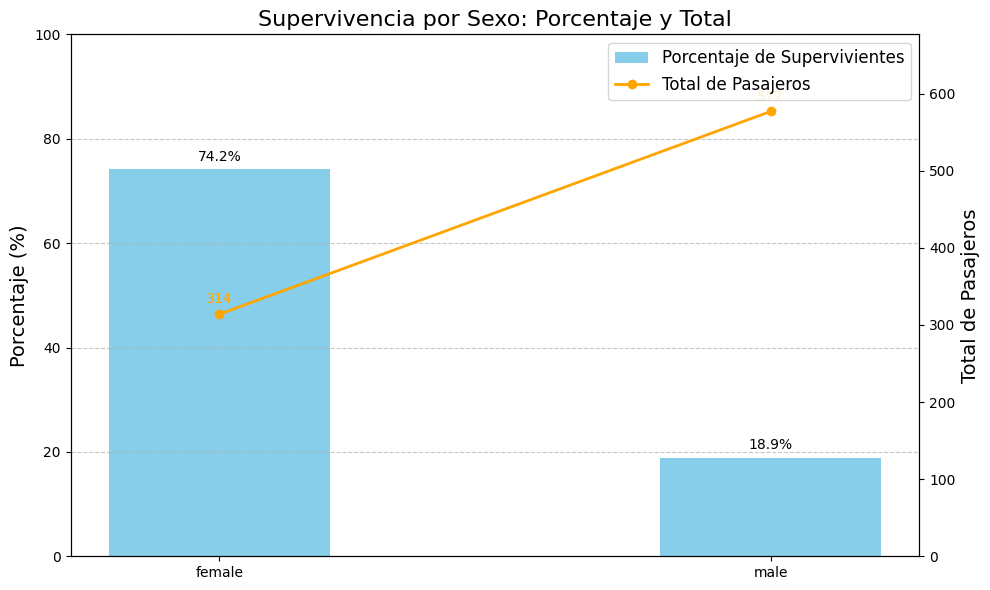

In [46]:
# Crear un gráfico combinado de barras y líneas para comparar el porcentaje y el total de supervivientes por sexo
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de barras para el porcentaje de supervivientes por sexo
bar_width = 0.4
bars = ax1.bar(
    supervivientes_por_sexo.index, 
    supervivientes_por_sexo['Porcentaje'], 
    color='skyblue', 
    width=bar_width, 
    label='Porcentaje de Supervivientes'
)

# Añadir etiquetas con el porcentaje en las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 1, 
        f"{height:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

# Configurar el eje y para el porcentaje
ax1.set_ylabel('Porcentaje (%)', fontsize=14)
ax1.set_ylim(0, 100)
ax1.set_title('Supervivencia por Sexo: Porcentaje y Total', fontsize=16)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Crear un segundo eje y para el total de pasajeros
ax2 = ax1.twinx()
ax2.plot(
    supervivientes_por_sexo.index, 
    supervivientes_por_sexo['Total'], 
    color='orange', 
    marker='o', 
    linewidth=2, 
    label='Total de Pasajeros'
)

# Añadir etiquetas con el total de pasajeros en el gráfico de líneas
for index, total in enumerate(supervivientes_por_sexo['Total']):
    ax2.text(
        index, 
        total + 10, 
        f"{int(total)}", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='orange'
    )

# Configurar el eje y para el total de pasajeros
ax2.set_ylabel('Total de Pasajeros', fontsize=14)
ax2.set_ylim(0, supervivientes_por_sexo['Total'].max() + 100)

# Añadir leyendas
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes, fontsize=12)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

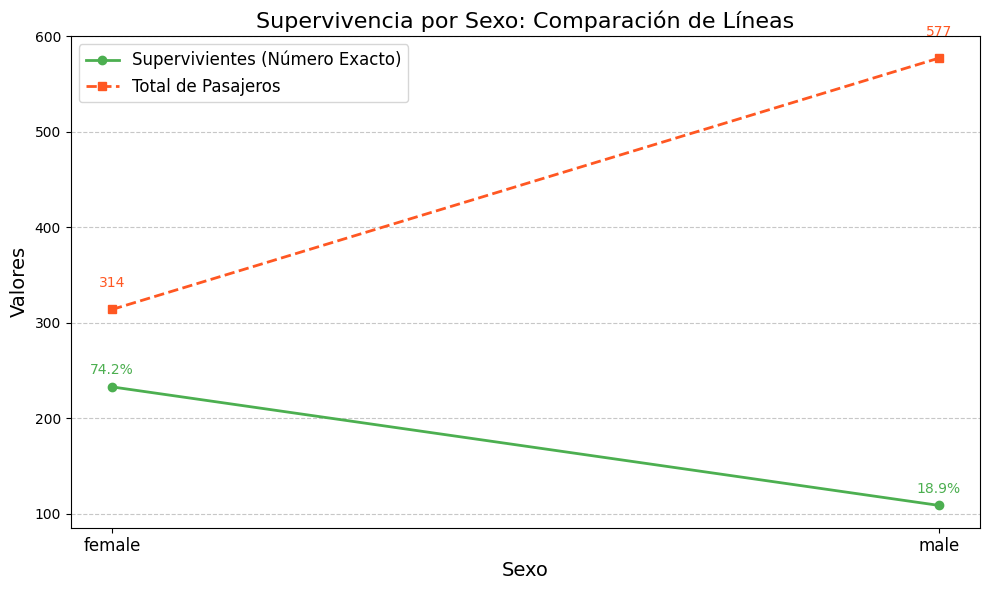

In [51]:
# Crear un gráfico de líneas para comparar el porcentaje y el total de supervivientes por sexo
plt.figure(figsize=(10, 6))

# Gráfico de líneas para el porcentaje de supervivientes por sexo
plt.plot(
    supervivientes_por_sexo.index, 
    supervivientes_por_sexo['Supervivientes'],  # Usar el número exacto de supervivientes
    marker='o', 
    linestyle='-', 
    color='#4CAF50', 
    linewidth=2, 
    label='Supervivientes (Número Exacto)'
)

# Gráfico de líneas para el total de pasajeros por sexo
plt.plot(
    supervivientes_por_sexo.index, 
    supervivientes_por_sexo['Total'], 
    marker='s', 
    linestyle='--', 
    color='#FF5722', 
    linewidth=2, 
    label='Total de Pasajeros'
)

# Añadir etiquetas a los puntos
for index, row in supervivientes_por_sexo.iterrows():
    plt.text(
        index, 
        row['Supervivientes'] + 10,  # Posicionar ligeramente por encima del número de supervivientes
        f"{row['Porcentaje']:.1f}%",  # Mostrar el porcentaje con el símbolo %
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='#4CAF50'
    )
    plt.text(
        index, 
        row['Total'] + 20, 
        f"{int(row['Total'])}",  # Mostrar el número total de pasajeros
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='#FF5722'
    )

# Configurar etiquetas y título
plt.title('Supervivencia por Sexo: Comparación de Líneas', fontsize=16)
plt.xlabel('Sexo', fontsize=14)
plt.ylabel('Valores', fontsize=14)
plt.xticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()
